In [357]:
# Q1 Import Libraries

In [358]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [359]:
# Q2 Load Dataset

In [360]:
train_df_df= pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")

In [361]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,DTI
count,539.000000,539.000000,539.000000,525.000000,492.000000,539.000000
mean,3880.606679,1723.443265,129.827458,342.400000,0.837398,0.040890
std,1589.910976,3010.534270,54.482048,65.915977,0.369377,0.057990
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.003785
25%,2698.500000,0.000000,100.000000,360.000000,1.000000,0.025339
50%,3547.000000,1447.000000,122.000000,360.000000,1.000000,0.032512
75%,4752.500000,2361.500000,152.500000,360.000000,1.000000,0.044330
max,8334.000000,41667.000000,495.000000,480.000000,1.000000,0.900000


In [362]:
#info

In [363]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            539 non-null    object 
 1   Gender             531 non-null    object 
 2   Married            537 non-null    object 
 3   Dependents         526 non-null    object 
 4   Education          539 non-null    object 
 5   Self_Employed      509 non-null    object 
 6   ApplicantIncome    539 non-null    int64  
 7   CoapplicantIncome  539 non-null    float64
 8   LoanAmount         539 non-null    float64
 9   Loan_Amount_Term   525 non-null    float64
 10  Credit_History     492 non-null    float64
 11  Property_Area      539 non-null    object 
 12  Loan_Status        539 non-null    object 
 13  DTI                539 non-null    float64
dtypes: float64(5), int64(1), object(8)
memory usage: 63.2+ KB


In [364]:
# Q3 Check Missing Values

In [365]:
train_df.isnull().sum()

,0
Loan_ID,0
Gender,8
Married,2
Dependents,13
Education,0
Self_Employed,30
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,14


Both Dataset Were loaded to understand datatype, missing values.

In [366]:
#Q4 Handle Missing Values in  Loan Amount (Median)

In [367]:
loan_median= train_df_df.groupby("Property_Area")["LoanAmount"].median()


In [368]:
loan_median

,LoanAmount
Property_Area,
Rural,133.0
Semiurban,127.5
Urban,120.0


In [ ]:
# Fill missing values using group median

train_df["LoanAmount"] = train_df["LoanAmount"].fillna(train_df.groupby("Property_Area")["LoanAmount"].transform('median'))

In [370]:
train_df["LoanAmount"]

,LoanAmount
0,120.0
1,128.0
2,66.0
3,120.0
4,141.0
...,...
609,71.0
610,40.0
611,253.0
612,187.0


In [371]:
# Why Median? Median is robust to outliers

In [372]:
# Q5 Outliers in Incomes (IQR Method)

In [373]:
Q1 = train_df['ApplicantIncome'].quantile(0.25)
Q3 = train_df['ApplicantIncome'].quantile(0.75)
IQR= Q3 - Q1

Lower_Bound = Q1-1.5 * IQR
Upper_Bound = Q3+1.5 * IQR

In [374]:
Lower_Bound

np.float64(-382.5)

In [375]:
Upper_Bound

np.float64(7833.5)

In [376]:
# Q6. Remove Outliers from Train Data (Using  IQR)

In [377]:
train_df = train_df[
    (train_df["ApplicantIncome"] >= Lower_Bound) &
    (train_df["ApplicantIncome"] <= Upper_Bound)]

In [378]:
train_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,DTI
0,LP001002,Male,No,0,Graduate,No,5849,0.0,120.0,360.0,1.0,Urban,Y,0.020516
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,0.027929
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.022000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,0.046458
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0.023500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y,0.033416
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,0.024483
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,0.009742
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,0.024660


In [379]:
# Q7 Average Loan Amount by Gender and  Property Areafor Credit History = 1.0

In [380]:
avg_loan = (
    train_df[train_df['Credit_History'] == 1.0]
    .groupby(['Gender', 'Property_Area'])['LoanAmount']
    .mean()
    .reset_index())

In [381]:
avg_loan

,Gender,Property_Area,LoanAmount
0,Female,Rural,118.421053
1,Female,Semiurban,109.042857
2,Female,Urban,99.411765
3,Male,Rural,132.173913
4,Male,Semiurban,132.860000
5,Male,Urban,122.266055


# Insight:
Applicants with valid credit history tend to qualifyfor higher loan amounts.

In [382]:
# Q8 Boxplot of  Applicant Income by Education


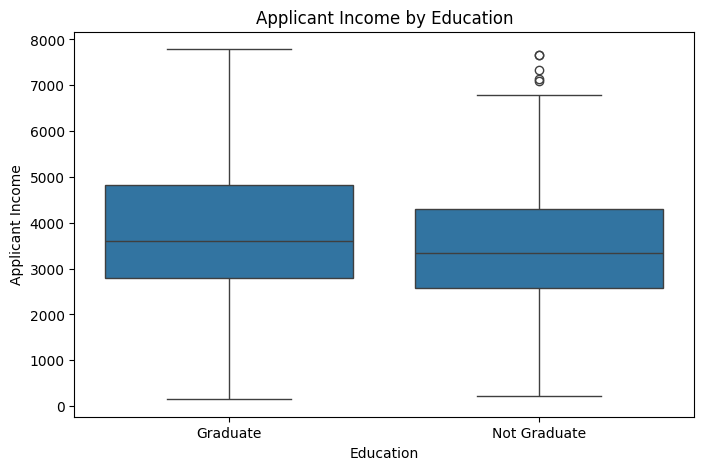

In [383]:


plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='ApplicantIncome', data=train_df)
plt.title('Applicant Income by Education')
plt.xlabel('Education')
plt.ylabel('Applicant Income')
plt.show()


#Insights
- Graduates generally earn more than Non-Graduates.
- Their median income is higher, and they also have more high-income outliers.
- Non-Graduates earn less on average with lower overall variation.

In [384]:
# Q9 Correlation Heatmap for numeric feature

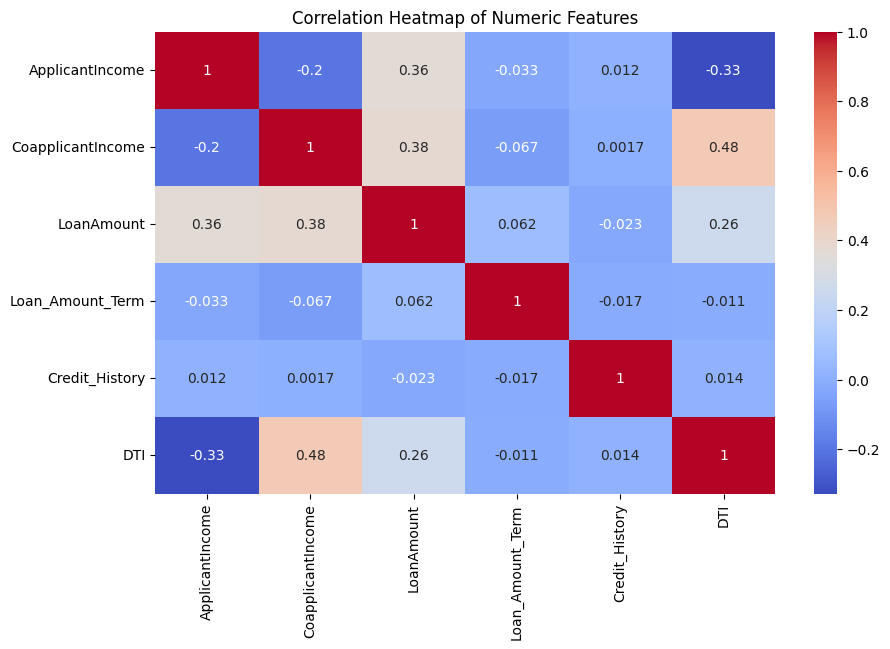

In [385]:
plt.figure(figsize=(10,6))
sns.heatmap(train_df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()



#Insights
 - LoanAmount is moderately correlated with both Applicant Income (0.42) and CoapplicantIncome (0.36) → higher income → higher loan amount.

- DTI has a strong positive correlation with Coapplicant Income (0.47) → co-applicant income impacts debt-to-income ratio.

- Applicant Income and DTI have a negative correlation (-0.31)
Credit_History has almost no correlation with numeric features.

- Loan_Amount_Term has very weak or no correlation with other variables

In [386]:
# Calculate Debt to income ratio(DTI)

In [ ]:
train_df["DTI"] = train_df["LoanAmount"] / train_df["ApplicantIncome"]


In [388]:
test_df["DTI"]

,DTI
0,0.020516
1,0.027929
2,0.022000
3,0.046458
4,0.023500
...,...
609,0.024483
610,0.009742
611,0.031343
612,0.024660


In [389]:
income_median = train_df["ApplicantIncome"].median()

In [390]:
income_median

3510.0

In [391]:
# Q11 Identify High-Risk Segments

In [392]:
train_df["DTI"] = train_df["LoanAmount"] / train_df["ApplicantIncome"]

/tmp/ipython-input-3602668924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["DTI"] = train_df["LoanAmount"] / train_df["ApplicantIncome"]


In [393]:
train_df["DTI"]

,DTI
0,0.020516
1,0.027929
2,0.022000
3,0.046458
4,0.023500
...,...
608,0.033416
609,0.024483
610,0.009742
612,0.024660


In [394]:
high_risk = train_df[
    (train_df["Property_Area"] == "Rural") &
    (train_df["ApplicantIncome"] < income_median) &
    (train_df["DTI"] > 0.40)]

In [395]:

high_risk

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,DTI
216,LP001722,Male,Yes,0,Graduate,No,150,1800.0,135.0,360.0,1.0,Rural,N,0.9


#Insights
- Applicants from rural areas with lower income levels and higher
debt-to-income ratios represent a higher credit risk.
- indicates increased repayment burden, particularly for applicants with
limited income capacity.


#Conclusion
- The analysis shows that credit history is the main factor for loan approval.
- People with low income and high loan amounts are more risky. Cleaning the data helped make the results more accurate.